In [99]:
import numpy as np
import h5py
import time
import inspect

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from helpers.config import *
from dataset_generation.noise_psd_gen import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, HDF5Glitch, Glitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [2]:
def make_tdi_dict(X, Y, Z, whiten=True):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        if whiten:
            psd_data = np.load(PSD_PATH / f'psd_{name}.npz')
            f_psd, psd = psd_data['f_psd'], psd_data['psd']
            tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd, alpha=0.1)
        else:
            tdi_dict[name] = channel_data[i]
    return tdi_dict

In [2]:
@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        old_stderr = sys.stderr
        sys.stdout = devnull
        sys.stderr = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout
            sys.stderr = old_stderr

In [3]:
params = np.loadtxt(DIST / 'inference_datasets' / 'lpf_datasets' / 'glitch_params_ordinary.txt', skiprows=1)

index = 10
amp = params[index, 1]
beta = params[index, 0]
level = 2*amp*beta

print(amp, beta, level)

2.777117629528859e-13 8.866439234077633 4.92462894162067e-12


In [3]:
params[:, 0], params[:, 1]

(array([8.66573074e-01, 3.77668607e-01, 2.12976482e+03, ...,
        2.70915071e-01, 4.56240462e+00, 6.50752090e+01],
       shape=(377,)),
 array([ 2.49834508e-13,  2.87276039e-13,  5.34774749e-12, ...,
        -2.68982420e-13,  1.08805870e-12,  2.14877413e-08],
       shape=(377,)))

In [4]:
pipe = {'t0':2136283130.8174996 + 10000.0, 'dt':0.25, 'size':int(10*3600/0.25)}

glitches = [{'type':'IntegratedShapeletGlitch', 't_inj': 5*3600, 'beta':beta,
             'level':-level, 'inj_point':'tm_12'}]
#glitches = [{'type':'ShapeletGlitch', 't_inj': 0, 'beta':1,
 #            'level':0, 'inj_point':'tm_12'}]

gws = [{'type': 'BinaryInspiralGW', 'm1': 1e6, 'm2': 1e6, 'd': 3e5,
        'spin1': 0.42, 'spin2': -0.42, 't_inj': 5*3600, 'domain': 'freq', 'gw_beta':0.09*np.pi, 'gw_lambda':1.09*np.pi}]

In [5]:
keep_noises = ['modulation', 'clock', 'test-mass', 'backlink', 'oms', 'ranging', 'angular-jitters', 'dws',\
               'moc-time-correlation', 'longitudinal-jitters']
keep_noises = ['test-mass', 'oms']

with suppress_output():
        run_simulation(
            gws, glitches, pipe,
            gw_path, None, orbits_path,
            simulation_path,
            disable_noise=['test-mass', 'oms']
        )
        raw_dict = run_tdi(simulation_path, pipe)

In [12]:
specs = {'low_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':6,
                       'drange':np.logspace(4, 5, 5)}}

In [13]:
event = glitches[0]
channel = 'A'
res = 256
spec = specs['low_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=True)

start = time.time()
#t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
 #                            frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr, f_arr, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

0.9553868770599365


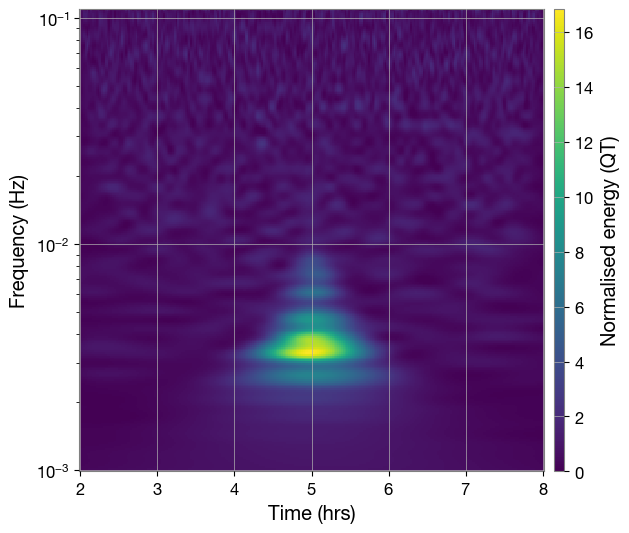

In [14]:
fig, axes = plt.subplots(1, 1, sharey=True, figsize=(6,6))
#title = f'level={event["level"]:.2e}, beta={event["beta"]:.2e}, inj_point={event["inj_point"]}'
#fig.suptitle(title, fontsize=16)

axes.pcolormesh(t_arr/3600, f_arr, QT, cmap='viridis')
axes.set_xlabel('Time (hrs)')
axes.set_ylabel('Frequency (Hz)')
axes.set_yscale('log')
axes.colorbar(label='Normalised energy (QT)')
plt.show()

## SNR calculation

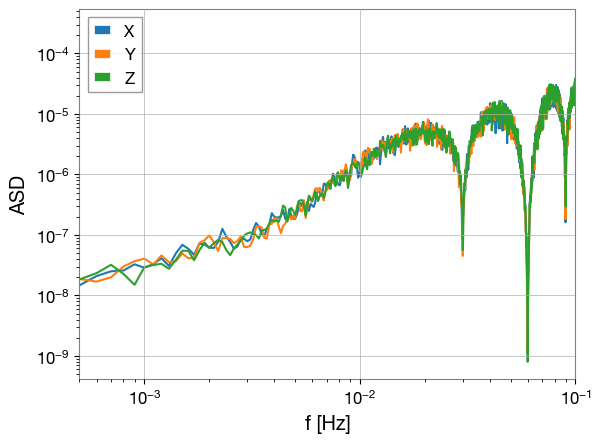

In [94]:
SX_sim = np.load(PSD_PATH / 'psd_X.npz')
SY_sim = np.load(PSD_PATH / 'psd_Y.npz')
SZ_sim = np.load(PSD_PATH / 'psd_Z.npz')

plt.loglog(SX_sim['f_psd'], np.sqrt(SX_sim['psd']), label='X')
plt.loglog(SY_sim['f_psd'], np.sqrt(SY_sim['psd']), label='Y')
plt.loglog(SZ_sim['f_psd'], np.sqrt(SZ_sim['psd']), label='Z')

plt.xlabel('f [Hz]')
plt.ylabel('ASD')
#plt.title('Everything except laser noise')
plt.xlim(5e-4, 1e-1)
#plt.ylim(1e-6, 1e-3)
plt.legend()
plt.show()

In [100]:
with h5py.File(glitch_lm_dataset_path, "r") as h5:
    amp_array = h5["amp"][:]
    beta_array = h5["beta"][:]
    #qt_array = h5["QT"][:]
    inj_array = h5['inj_point'][:]
    X_array = h5['X'][:]
    Y_array = h5['Y'][:]
    Z_array = h5['Z'][:]

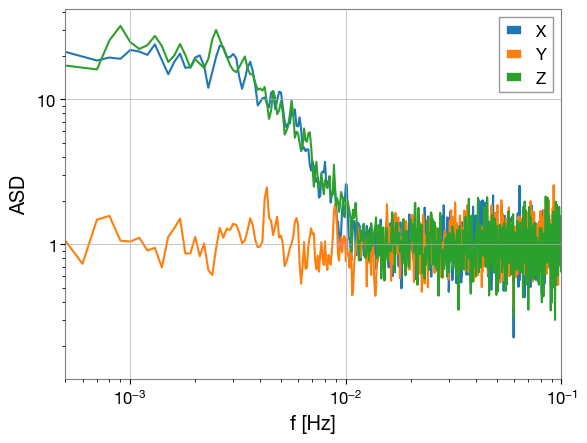

In [106]:
index = 2
X, Y, Z = X_array[index], Y_array[index], Z_array[index]
tdi_dict = make_tdi_dict(X, Y, Z, whiten=True)

f_psd1, psd1 = estimate_psd(tdi_dict['X'], 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd2, psd2 = estimate_psd(tdi_dict['Y'], 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd3, psd3 = estimate_psd(tdi_dict['Z'], 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)

plt.loglog(f_psd1, np.sqrt(psd1), label='X')
plt.loglog(f_psd2, np.sqrt(psd2), label='Y')
plt.loglog(f_psd3, np.sqrt(psd3), label='Z')

plt.xlabel('f [Hz]')
plt.ylabel('ASD')
#plt.title('Everything except laser noise')
plt.xlim(5e-4, 1e-1)
#plt.ylim(1e-6, 1e-3)
plt.legend()
plt.show()

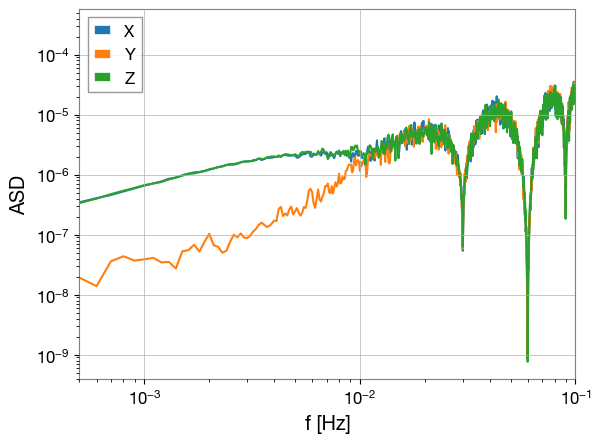

In [107]:
f_psd1, psd1 = estimate_psd(X, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd2, psd2 = estimate_psd(Y, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)
f_psd3, psd3 = estimate_psd(Z, 1/PIPE['dt'], nperseg=1e4/PIPE['dt'], noverlap=None)

plt.loglog(f_psd1, np.sqrt(psd1), label='X')
plt.loglog(f_psd2, np.sqrt(psd2), label='Y')
plt.loglog(f_psd3, np.sqrt(psd3), label='Z')

plt.xlabel('f [Hz]')
plt.ylabel('ASD')
#plt.title('Everything except laser noise')
plt.xlim(5e-4, 1e-1)
#plt.ylim(1e-6, 1e-3)
plt.legend()
plt.show()

In [72]:
with h5py.File(INFERENCE_DATASETS / 'glitch_datasets'/ 'lpf_glitch_ehm_dataset.h5', "r") as h5:
    amp_array = h5["amp"][:]
    beta_array = h5["beta"][:]
    qt_array = h5["QT"][:]

In [76]:
params = np.loadtxt(lpf_ord_param_path, skiprows=1)

lpf_betas = params[:, 0]
lpf_amps = params[:, 1]
lpf_snrs = params[:, 2]

In [ ]:
"""h5 = h5py.File(glitch_dataset_path, "r+")
del h5['QT']
del h5['t_qscan']
del h5['f_qscan']
del h5['tcen']
h5.close()"""

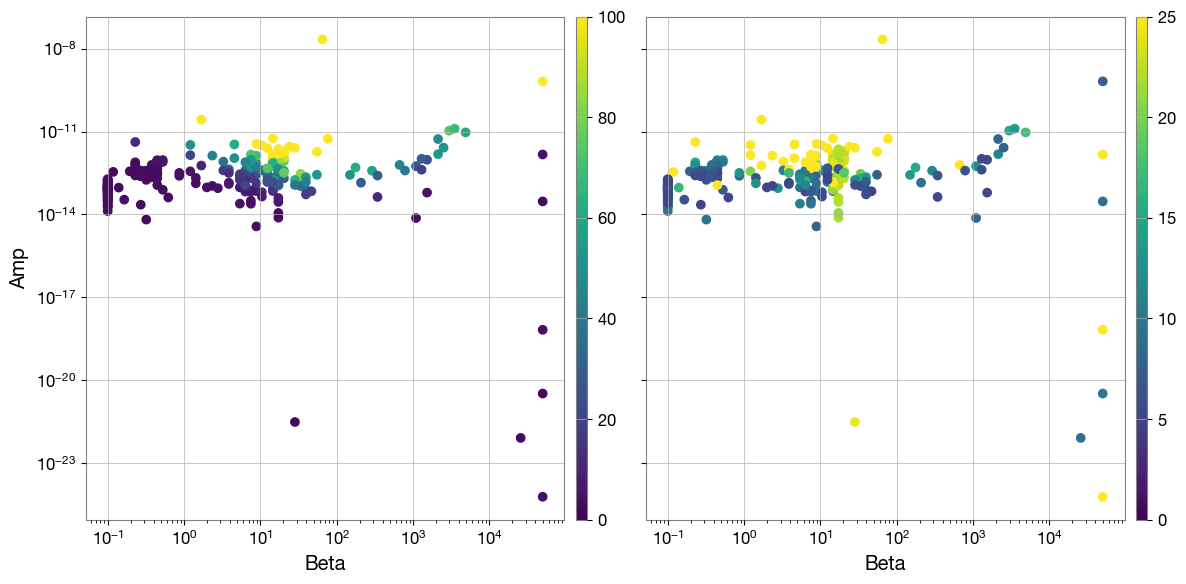

In [84]:
images = qt_array[:, 2, :, :, :]
snrs = np.max(images, axis=(1,2,3))

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True, tight_layout=True)
axes[0].scatter(beta_array, np.abs(amp_array), c=snrs, cmap='viridis')
axes[1].scatter(lpf_betas, np.abs(lpf_amps), c=lpf_snrs, cmap='viridis')
axes[0].set_xlabel('Beta')
axes[1].set_xlabel('Beta')
axes[0].set_ylabel('Amp')
axes[0].set_xscale('log')
axes[1].set_xscale('log')
axes[0].set_yscale('log')
axes[0].colorbar(clim=(0, 100))
axes[1].colorbar(clim=(0, 25))
plt.show()

In [92]:
np.where((beta_array < 1) & (snrs > 10))

(array([56]),)

4.179306e-12 0.2294533 11.20721 11.20721


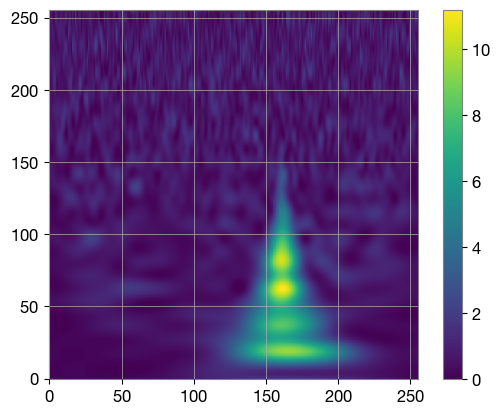

In [93]:
index = 56
image = qt_array[index][2]
print(amp_array[index], beta_array[index], snrs[index], np.max(image))
plt.imshow(image[:,:,0], origin='lower')
plt.colorbar()
plt.show()